# Социальная сеть участников судебных дел первой половины XVII века в Устюге Великом  
## По мирским челобитным и связанным делопроизводственным документам

**Материал:** сводная таблица, составленная по челобитным, указным грамотам, кабалам, поручным записям, памятям, отпискам и другим документам Устюжской четверти. Прилагаю также файл с сырыми данными

### Исследовательский вопрос
Какие участники и институты занимали центральное положение в судебных конфликтах Устюга Великого первой половины XVII века, и через какие типы связей община защищала свои интересы?

### Гипотеза
Защита интересов общины была не только формально-судебной процедурой, но и сетью практик: челобитья, поручительства, займов, выбора представителей, отказов от выплат и контроля над собственными посыльщиками. Поэтому центральными в графе должны оказаться не только отдельные истцы и ответчики, но и приказные учреждения, выборные должностные лица, посадские люди и кредиторы.


## 1. План работы

1. Загрузить структурированные данные из Excel-файла.
2. Проверить объём корпуса: в исследовании должно учитываться **199 документов**.
3. Очистить и нормализовать типы документов, даты, суммы и архивные ссылки.
4. Построить первичную статистику по корпусу.
5. Визуализировать способы защиты интересов общины.
6. Извлечь ключевых участников и построить сетевую модель.
7. Посчитать показатели центральности и интерпретировать результат.
8. Сохранить таблицы и визуализации для GitHub-репозитория.




In [92]:

from pathlib import Path
import re
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display, Markdown

pd.set_option('display.max_colwidth', 180)
pd.set_option('display.max_rows', 100)

# Папки для результатов
OUTPUT_DIR = Path('outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 160


## 2. Загрузка данных



In [93]:
DATA_PATH = Path("защита_общины_199.xlsx")
df = pd.read_excel(DATA_PATH)


In [94]:
def find_sheet(part: str) -> str:
    """Находит лист по фрагменту названия."""
    matches = [s for s in xls.sheet_names if part.lower() in s.lower()]
    if not matches:
        raise ValueError(f'Не найден лист, содержащий: {part!r}')
    return matches[0]

main_sheet = find_sheet('Документы')
strategy_sheet = find_sheet('Сводка')
detail_strategy_sheet = find_sheet('способы')
case75_sheet = find_sheet('дело 75')

raw_df = pd.read_excel(DATA_PATH, sheet_name=main_sheet)
strategy_summary = pd.read_excel(DATA_PATH, sheet_name=strategy_sheet)
strategy_details = pd.read_excel(DATA_PATH, sheet_name=detail_strategy_sheet)
case75_df = pd.read_excel(DATA_PATH, sheet_name=case75_sheet)

print('Основной лист:', main_sheet, '| строк с заголовком:', len(raw_df))
print('Лист со способами защиты:', strategy_sheet, '| строк:', len(strategy_summary))


Основной лист: Документы-все 199 | строк с заголовком: 197
Лист со способами защиты: Сводка защиты интересов | строк: 11


## 3. Очистка таблицы



In [95]:
# Переименуем столбцы
rename_map = {
    'Архивная ссылка': 'archive_ref',
    'Дата': 'date_raw',
    'Тип документа': 'doc_type',
    'Листы': 'sheets',
    'Денежные суммы, руб.': 'amounts_rub_raw',
    'Название / описание документа': 'description',
    'ПРИМЕЧАНИЕ': 'note',
}

df = raw_df.rename(columns=rename_map).copy()

# Оставим только содержательные строки
important_cols = ['archive_ref', 'date_raw', 'doc_type', 'sheets', 'amounts_rub_raw', 'description', 'note']
df = df[[c for c in important_cols if c in df.columns]]
df = df.dropna(how='all')
df = df[df[['archive_ref', 'doc_type', 'description']].notna().any(axis=1)].copy()
df = df.reset_index(drop=True)
df['row_id'] = np.arange(1, len(df) + 1)

def normalize_doc_type(value) -> str:
    t = str(value).strip().lower()
    if not t or t == 'nan':
        return 'Не указано'
    if 'челобит' in t:
        return 'Челобитная'
    if 'указ' in t and 'грамот' in t:
        return 'Указная грамота'
    if 'кабал' in t:
        return 'Заемная кабала'
    if 'поручн' in t:
        return 'Поручная запись'
    if 'отпис' in t or 'отпись' in t:
        return 'Отписка / отпись'
    if 'наказ' in t and 'пам' in t:
        return 'Наказная память'
    if 'пам' in t:
        return 'Память'
    if 'приговор' in t or 'обязатель' in t or 'запись' in t:
        return 'Запись / приговор'
    if 'допрос' in t:
        return 'Допрос'
    if 'сказк' in t:
        return 'Сказка'
    return str(value).strip().capitalize()

def extract_year(*values):
    text = ' '.join('' if pd.isna(v) else str(v) for v in values)
    m = re.search(r'\b(16\d{2})\b', text)
    return int(m.group(1)) if m else np.nan

def parse_amounts(value):
    """Извлекает суммы из ячейки с денежными значениями. Возвращает список чисел."""
    if pd.isna(value):
        return []
    text = str(value).replace('\xa0', ' ')
    nums = re.findall(r'\d+(?:[\.,]\d+)?', text)
    return [float(n.replace(',', '.')) for n in nums]

def extract_archive_case(value):
    """Приводит архивную ссылку к уровню дела: Ф. 141. Оп. ... Д. ..."""
    if pd.isna(value):
        return 'Не указано'
    text = str(value)
    m = re.search(r'Ф\.\s*141\.\s*Оп\.\s*([12])\.\s*(\d{4})\.\s*Д\.\s*(\d+)', text)
    if m:
        return f'Оп. {m.group(1)}. {m.group(2)}. Д. {m.group(3)}'
    return 'Другое / не распознано'

def infer_doc_weight(note):
    """Сколько документных единиц скрыто в одной строке таблицы."""
    if pd.isna(note):
        return 1
    t = str(note).lower().replace('ё', 'е')

    if 'формально документ один' in t and 'еще два' in t:
        return 3
    m = re.search(r'еще\s+(\d+)\s+док', t)
    if m:
        return 1 + int(m.group(1))
    return 1

df['doc_type_norm'] = df['doc_type'].apply(normalize_doc_type)
df['year'] = df.apply(lambda r: extract_year(r.get('date_raw'), r.get('description')), axis=1)
df['archive_case'] = df['archive_ref'].apply(extract_archive_case)
df['amounts_list'] = df['amounts_rub_raw'].apply(parse_amounts)
df['amount_total'] = df['amounts_list'].apply(sum)
df['doc_weight'] = df['note'].apply(infer_doc_weight).astype(int)
df['text_all'] = df[['date_raw', 'doc_type', 'description', 'note']].fillna('').agg(' '.join, axis=1)

# Разворачиваем строки в документные единицы
docs_df = df.loc[df.index.repeat(df['doc_weight'])].copy().reset_index(drop=True)
docs_df['doc_unit_in_row'] = docs_df.groupby('row_id').cumcount() + 1
docs_df['doc_id'] = docs_df.apply(lambda r: f"D{int(r['row_id']):03d}.{int(r['doc_unit_in_row'])}", axis=1)

print('Документных единиц после разворачивания:', len(docs_df))

assert len(docs_df) == 199, f'Ожидалось 199 документов, получилось {len(docs_df)}'

display(df.loc[df['doc_weight'] > 1, ['row_id', 'archive_ref', 'date_raw', 'doc_type_norm', 'description', 'note', 'doc_weight']])


Документных единиц после разворачивания: 199


,row_id,archive_ref,date_raw,doc_type_norm,description,note,doc_weight
13,14,Ф. 141. Оп. 1. 1626. Д. 15. Л. 552-573.,1632 г.,Челобитная,"1632 г. челобитная устюжских мирских посыльщиков Саввы Пинегина с товарищами о выдаче денег на корм и питье послам и посланникам из казны, а не из мирских денег. Л. 552-573","формально документ один, но из него видно, что было еще два",3


## 4. Первичный обзор корпуса

Сначала посмотрим, какие типы документов преобладают и как документы распределяются по годам. Это важно для интерпретации, судебное дело в XVII веке фиксируется не одной челобитной, а серией документов — грамот, памятей, поручных записей, кабал, отписок.


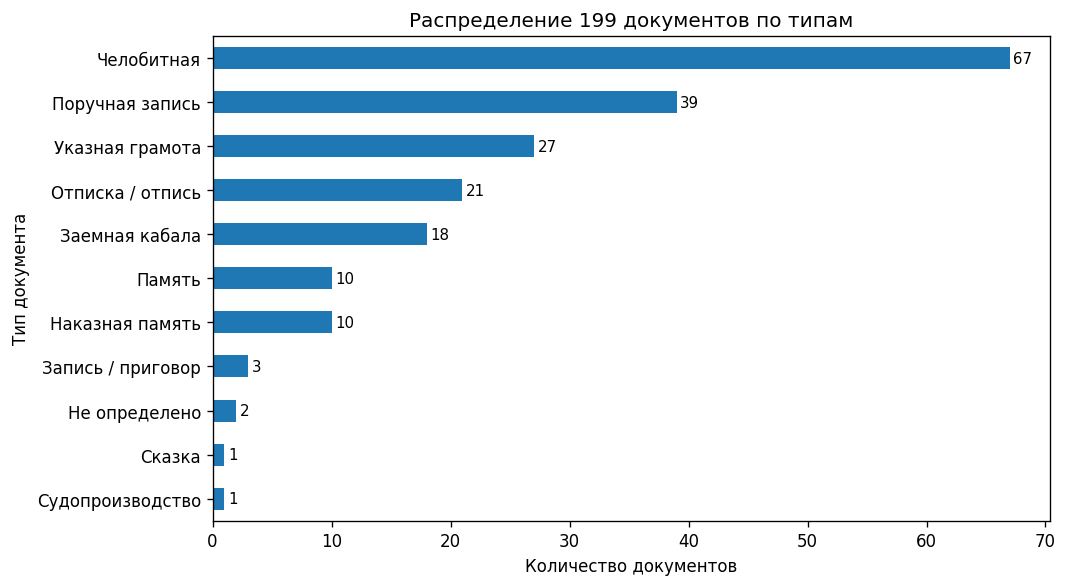

,Количество
doc_type_norm,
Челобитная,67
Поручная запись,39
Указная грамота,27
Отписка / отпись,21
Заемная кабала,18
Память,10
Наказная память,10
Запись / приговор,3
Не определено,2


In [96]:
doc_type_counts = docs_df['doc_type_norm'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
doc_type_counts.plot(kind='barh', ax=ax)
ax.set_title('Распределение 199 документов по типам')
ax.set_xlabel('Количество документов')
ax.set_ylabel('Тип документа')
for i, v in enumerate(doc_type_counts):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_document_types.png', bbox_inches='tight')
plt.show()

display(doc_type_counts.sort_values(ascending=False).rename('Количество').to_frame())


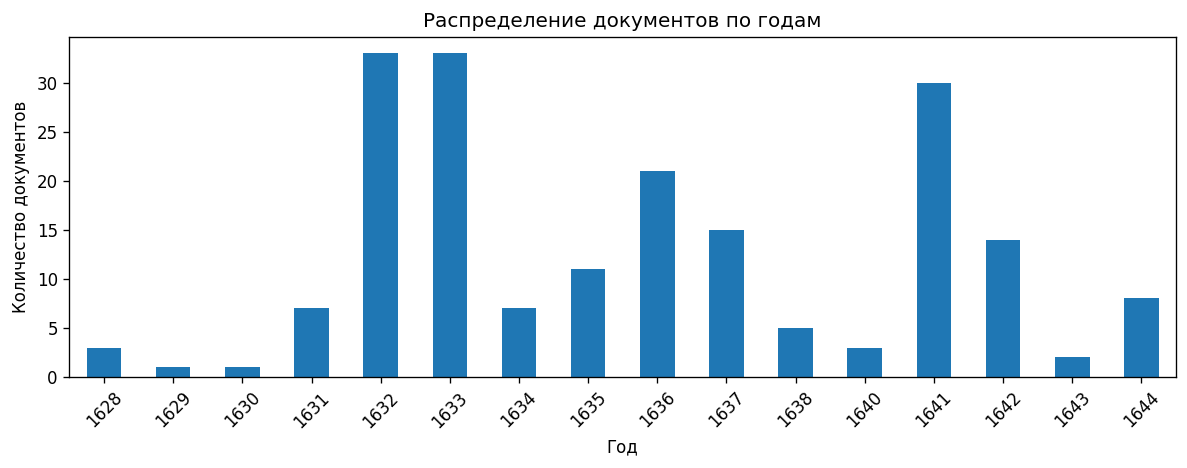

,Количество документов
year,
1628,3
1629,1
1630,1
1631,7
1632,33
1633,33
1634,7
1635,11
1636,21


In [97]:
year_counts = docs_df.dropna(subset=['year']).copy()
year_counts['year'] = year_counts['year'].astype(int)
year_counts = year_counts['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
year_counts.plot(kind='bar', ax=ax)
ax.set_title('Распределение документов по годам')
ax.set_xlabel('Год')
ax.set_ylabel('Количество документов')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_documents_by_year.png', bbox_inches='tight')
plt.show()

display(year_counts.rename('Количество документов').to_frame())


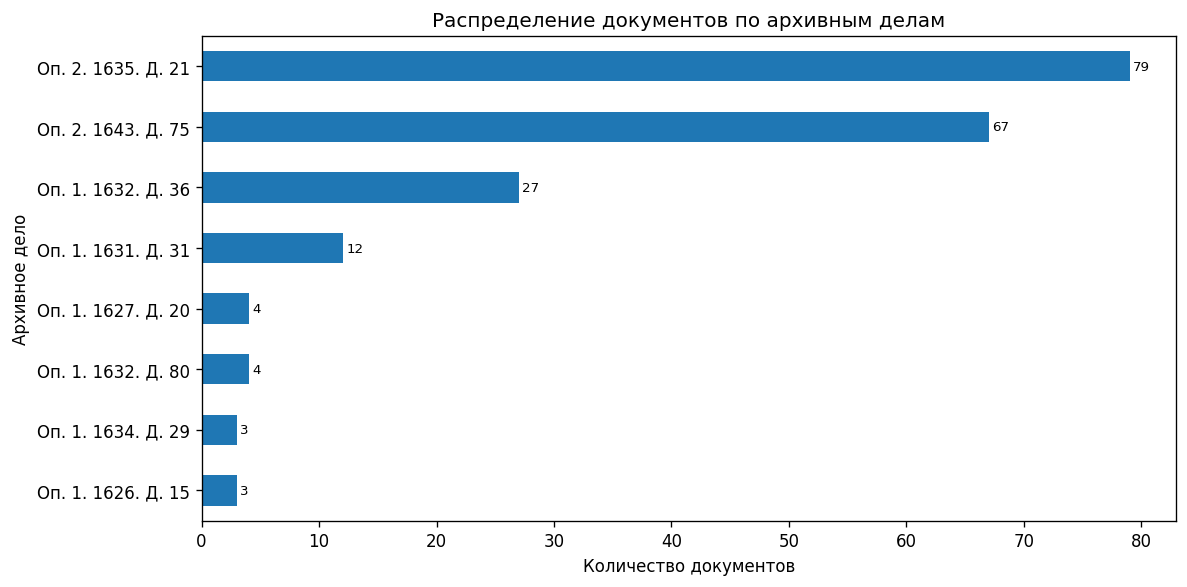

,Количество
archive_case,
Оп. 2. 1635. Д. 21,79
Оп. 2. 1643. Д. 75,67
Оп. 1. 1632. Д. 36,27
Оп. 1. 1631. Д. 31,12
Оп. 1. 1632. Д. 80,4
Оп. 1. 1627. Д. 20,4
Оп. 1. 1626. Д. 15,3
Оп. 1. 1634. Д. 29,3


In [98]:
case_counts = docs_df['archive_case'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
case_counts.plot(kind='barh', ax=ax)
ax.set_title('Распределение документов по архивным делам')
ax.set_xlabel('Количество документов')
ax.set_ylabel('Архивное дело')
for i, v in enumerate(case_counts):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_archive_cases.png', bbox_inches='tight')
plt.show()

display(case_counts.sort_values(ascending=False).rename('Количество').to_frame().head(15))


### Матрица «год × тип документа»

Эта визуализация помогает увидеть, какие типы документов концентрируются в отдельные годы. Например, рост числа челобитных или указных грамот может показывать обострение тяжбы и активизацию приказной переписки.


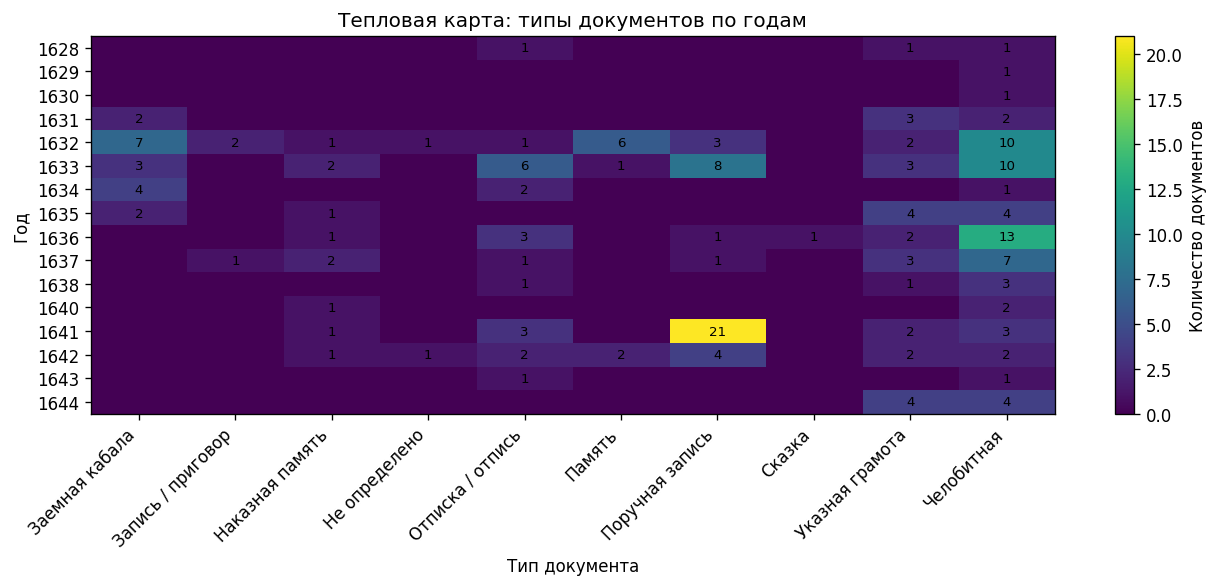

doc_type_norm,Заемная кабала,Запись / приговор,Наказная память,Не определено,Отписка / отпись,Память,Поручная запись,Сказка,Указная грамота,Челобитная
year,,,,,,,,,,
1628,0,0,0,0,1,0,0,0,1,1
1629,0,0,0,0,0,0,0,0,0,1
1630,0,0,0,0,0,0,0,0,0,1
1631,2,0,0,0,0,0,0,0,3,2
1632,7,2,1,1,1,6,3,0,2,10
1633,3,0,2,0,6,1,8,0,3,10
1634,4,0,0,0,2,0,0,0,0,1
1635,2,0,1,0,0,0,0,0,4,4
1636,0,0,1,0,3,0,1,1,2,13


In [99]:
heat_df = docs_df.dropna(subset=['year']).copy()
heat_df['year'] = heat_df['year'].astype(int)
heat_table = pd.crosstab(heat_df['year'], heat_df['doc_type_norm'])

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(heat_table.values, aspect='auto')
ax.set_title('Тепловая карта: типы документов по годам')
ax.set_xlabel('Тип документа')
ax.set_ylabel('Год')
ax.set_xticks(np.arange(len(heat_table.columns)))
ax.set_xticklabels(heat_table.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(len(heat_table.index)))
ax.set_yticklabels(heat_table.index)

for i in range(heat_table.shape[0]):
    for j in range(heat_table.shape[1]):
        value = heat_table.iloc[i, j]
        if value:
            ax.text(j, i, str(value), ha='center', va='center', fontsize=8)

fig.colorbar(im, ax=ax, label='Количество документов')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_year_type_heatmap.png', bbox_inches='tight')
plt.show()

display(heat_table)


Более частое челобитье выделяется в те годы, когда в Устюге были восстания, что примечательно и показательно.

## 5. Денежные суммы в документах

Денежные суммы особенно важны для дел о кабалах, правеже, долгах и убытках. В поле `amount_total` суммируются все числовые значения, которые были занесены в отдельную колонку таблицы. Это даёт возможность увидеть масштаб денежных конфликтов.


In [100]:
amount_docs = docs_df[docs_df['amount_total'] > 0].copy()
print('Документов с указанными денежными суммами:', len(amount_docs))
print('Суммарно распознано рублей:', round(amount_docs['amount_total'].sum(), 2))

display(amount_docs[['doc_id', 'date_raw', 'doc_type_norm', 'archive_ref', 'amounts_rub_raw', 'amount_total', 'description']].head(20))


Документов с указанными денежными суммами: 38
Суммарно распознано рублей: 14762.0


,doc_id,date_raw,doc_type_norm,archive_ref,amounts_rub_raw,amount_total,description
3,D004.1,1629 г. марта 18,Челобитная,Ф. 141. Оп. 1. 1627. Д. 20. Л. 247.,"10, 185, 43, 9, 30, 235",512.0,1629 г. марта 18. – Челобитная посадского г. Устюга Великого Федора Астафьева сына Винокура о даче суда с посадскими Саввой Ивановым сыном Пинегина по делу о причинении убытков...
9,D010.1,1631 г. ноября 27,Заемная кабала,Ф. 141. Оп. 2. 1635. Д. 21. Л. 115.,200,200.0,"1631 г. ноября 27. – Заемная кабала Артемия Никитина сына Аноховского, Федора Григорьева сына Болтина и Саввы Иванова сына Пинегина кн. Никифору Ивановичу Белосельскому в 200 р..."
12,D013.1,1631 г.,Заемная кабала,Ф. 141. Оп. 1. 1632. Д. 36. Л. 279.,200,200.0,"1631 г., ноября 27. -Заемная кабала «посыльщиков» Устюга Великого Артемия Никитина сына Аноховского, Федора Григорьева сына Болтина и Саввы Иванова сына Пинегина кн. Никифору И..."
24,D023.1,1632 г. июля 7,Заемная кабала,Ф. 141. Оп. 2. 1635. Д. 21. Л. 103.,20,20.0,1632 г. июля 7. – Заемная кабала «посыльщиков» с Утюга Великого Артемия Никитина сына Аноховского и Саввы Иванова сына Пинегина Филиппу Кузьмину сыну Фролова в 20 рублях сроком...
25,D024.1,1632 г. июля 9,Челобитная,"Ф. 141. Оп. 1. 1632. Д. 36. Л. 145; 146, 147.",120,120.0,"1632 г. июля 9. – Челобитная (первая) посадского г. Устюга Великого Саввы Иванова сына Пинегина о даче суда с Сидором Кузне цовым, Семеном Черепановым и другими посадскими и кр..."
29,D028.1,1632 г. июня 25,Заемная кабала,"Ф. 141. Оп. 2. 1635. Д. 21. Л. 111, 112.",200,200.0,1632 г. июня 25. – Заемная кабала Артемия Никитина сына Аноховского и Саввы Иванова сына Пинегина крестьянину Троице-Сергиева м-ря Петру Дементьеву сыну Мельникова в 200 рублях...
30,D029.1,1632 г. июня 26,Заемная кабала,Ф. 141. Оп. 2. 1635. Д. 21. Л. 113.,50,50.0,1632 г. июня 26. – Заемная кабала Артемия Никитина сына Аноховского и Саввы Иванова сына Пинегина крестьянину Троице-Сергиева м-ря Петру Дементьеву сыну Мельникова в 50 рублях ...
31,D030.1,1632 г. июня 26,Заемная кабала,Ф. 141. Оп. 2. 1635. Д. 21. Л. 104.,100,100.0,"1632 г. июня 26. – Заемная кабала посадского Устюга Великого Артемия Никитина сына аноховского, Саввы Иванова сына Пинегина и Дмитрия Емельянова сына Котельникова Филиппу Кузьм..."
39,D038.1,1632 г. сентября 2,Заемная кабала,Ф. 141. Оп. 2. 1635. Д. 21. Л. 91-94.,1000,1000.0,"1632 г. сентября 2. – Заемная кабала стряпчего Архангельского великоустюжского м-ря Ивана Семенова, земских судеек Устюга Великого Ивана Моисеева сына Завалина, Григория Юрьева..."
40,D039.1,1632 г. сентября 25,Заемная кабала,Ф. 141. Оп. 2. 1635. Д. 21. Л. 102.,2000,2000.0,"1632 г. сентября 25. – Заемная кабала земских судеек Устюга Великого Ивана Моисеева сына Завалина, Григория Юрьева сына Губина и других торговцу Гостиной сотни Кириллу Алексеев..."


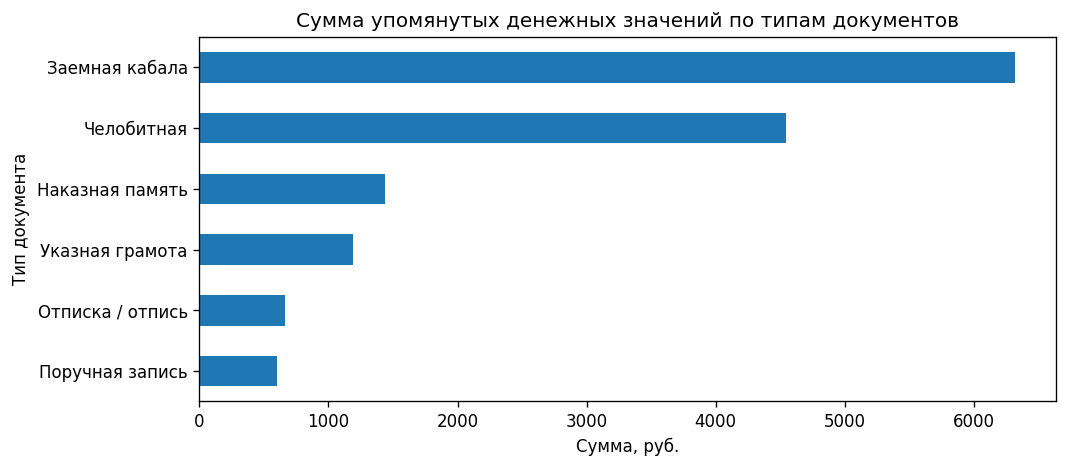

,"Сумма, руб."
doc_type_norm,
Заемная кабала,6320.0
Челобитная,4544.0
Наказная память,1440.0
Указная грамота,1194.0
Отписка / отпись,664.0
Поручная запись,600.0


In [101]:
amount_by_type = amount_docs.groupby('doc_type_norm')['amount_total'].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
amount_by_type.plot(kind='barh', ax=ax)
ax.set_title('Сумма упомянутых денежных значений по типам документов')
ax.set_xlabel('Сумма, руб.')
ax.set_ylabel('Тип документа')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_amounts_by_doc_type.png', bbox_inches='tight')
plt.show()

display(amount_by_type.sort_values(ascending=False).rename('Сумма, руб.').to_frame())


## 6. Способы защиты интересов общины

Отдельный лист Excel содержит ручную классификацию способов защиты интересов общины. Здесь важно учитывать, что один документ может попадать сразу в несколько практик: например, челобитье может одновременно быть ходатайством, частью судебного представительства и элементом борьбы за правеж. Поэтому суммы по практикам **не обязаны складываться в 199**.


In [102]:
# Приведем сводку способов защиты к удобному виду
strat = strategy_summary.copy()
strat = strat.rename(columns={
    strat.columns[0]: 'strategy',
    strat.columns[1]: 'count'
})
strat = strat.dropna(subset=['strategy', 'count']).copy()
strat['count'] = pd.to_numeric(strat['count'], errors='coerce')
strat = strat.dropna(subset=['count'])
strat['count'] = strat['count'].astype(int)

def strategy_group(name: str) -> str:
    t = str(name).lower()
    if any(k in t for k in ['ходатайство', 'представительство', 'займы', 'поручительство', 'правеж', 'непривлечение']):
        return 'Через посредника / правовую процедуру'
    return 'Самозащита / внутренний контроль'

strat['group'] = strat['strategy'].apply(strategy_group)
strat_sorted = strat.sort_values('count')

display(strat.sort_values('count', ascending=False))


,strategy,count,group
10,Займы,120,Через посредника / правовую процедуру
9,Судебное представительство,94,Через посредника / правовую процедуру
8,Ходатайство через челобитные,81,Через посредника / правовую процедуру
7,отказ в утверждении отчета,29,Самозащита / внутренний контроль
5,отказ от поручительства и выплат,18,Самозащита / внутренний контроль
2,"неурожаи, бедность, разорение",9,Самозащита / внутренний контроль
4,вооруженный протест / сопротивление властям,9,Самозащита / внутренний контроль
3,мир / помирились,8,Самозащита / внутренний контроль
0,отказ в выборе ответчиков,3,Самозащита / внутренний контроль
6,обвинить посыльного в сговоре,2,Самозащита / внутренний контроль


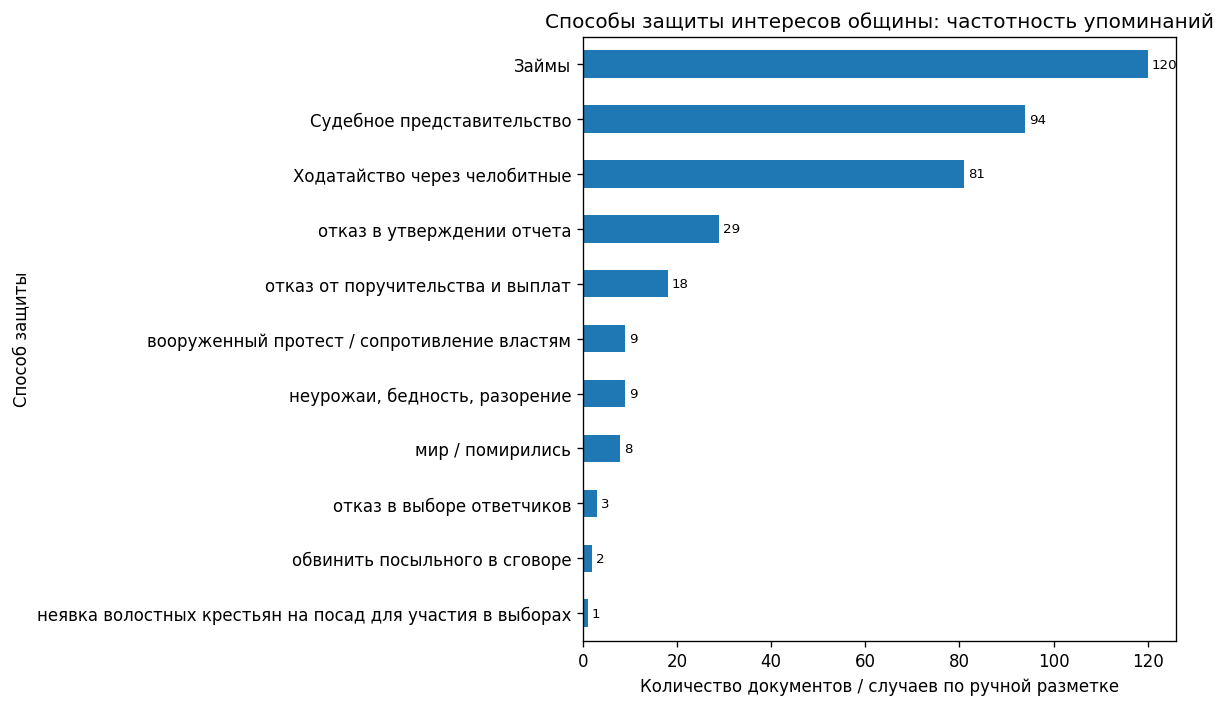

In [103]:
fig, ax = plt.subplots(figsize=(10, 6))
strat_sorted.plot(x='strategy', y='count', kind='barh', ax=ax, legend=False)
ax.set_title('Способы защиты интересов общины: частотность упоминаний')
ax.set_xlabel('Количество документов / случаев по ручной разметке')
ax.set_ylabel('Способ защиты')
for i, v in enumerate(strat_sorted['count']):
    ax.text(v + 0.8, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_protection_strategies.png', bbox_inches='tight')
plt.show()


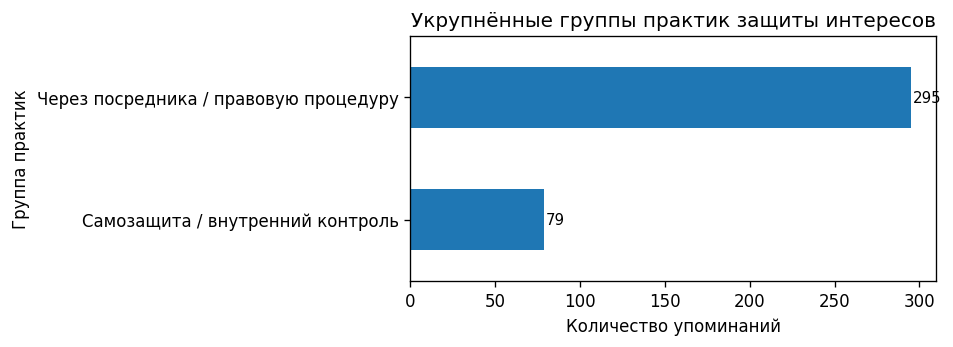

,group,count
0,Самозащита / внутренний контроль,79
1,Через посредника / правовую процедуру,295


In [104]:
group_summary = strat.groupby('group', as_index=False)['count'].sum().sort_values('count')

fig, ax = plt.subplots(figsize=(8, 3))
group_summary.plot(x='group', y='count', kind='barh', ax=ax, legend=False)
ax.set_title('Укрупнённые группы практик защиты интересов')
ax.set_xlabel('Количество упоминаний')
ax.set_ylabel('Группа практик')
for i, v in enumerate(group_summary['count']):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_strategy_groups.png', bbox_inches='tight')
plt.show()

display(group_summary)


Таким образом, видно, что чаще община прибегала к найму посредника для защиты своих интересов

## 7. Подготовка данных для сетевого анализа на основе названий документов

Автоматическое извлечение имён из актовых текстов XVII века невозможно сделать без ошибок: встречаются варианты написания, сокращения, повреждённые фрагменты, родительный и дательный падежи. Поэтому используется смешанный подход:

- по ключевым словам и регулярным выражениям выделяются устойчиво распознаваемые участники;
- разные варианты написания приводятся к нормализованному имени;
- коллективные субъекты сохраняются как отдельные узлы: посадские люди, волостные крестьяне, выборные должностные лица, Устюжская четверть;
- тип связи определяется по типу документа и ключевым словам описания.




In [105]:
ENTITY_PATTERNS = [
    # ключевые частные лица
    (r'Савв[а-яё]*\s+Иванов|Савк[а-яё]*|Пинегин[а-яё]*', 'Савва Иванов сын Пинегин', 'частное лицо / посыльщик'),
    (r'Артем[ийья][а-яё]*\s+Никитин|Ортем[а-яё]*|Аноховск[а-яё]*|Оноховск[а-яё]*', 'Артемий Никитин сын Аноховский', 'частное лицо / посыльщик'),
    (r'Федор[а-яё]*\s+Григорьев[а-яё]*\s+сын[а-яё]*\s+Болтин|Федк[а-яё]*\s+Болтин|Болтин[а-яё]*', 'Федор Григорьев сын Болтин', 'частное лицо / посыльщик'),
    (r'Иван[а-яё]*\s+Моисеев[а-яё]*\s+сын[а-яё]*\s+Завалин|Завалин[а-яё]*', 'Иван Моисеев сын Завалин', 'выборное лицо / должник'),
    (r'Васили[йья][а-яё]*\s+Емельянов[а-яё]*|Котельников[а-яё]*', 'Василий Емельянов сын Котельников', 'подьячий / участник дела'),
    (r'Григор[ийья][а-яё]*\s+Похабов|Похабов[а-яё]*', 'Григорий Похабов', 'подьячий / участник дела'),
    (r'Петр[а-яё]*\s+Выломаев|Выломаев[а-яё]*', 'Петр Выломаев', 'ямской староста / ответчик'),
    (r'Кирилл[а-яё]*\s+Верещагин|Верещагин[а-яё]*', 'Кирилл Верещагин', 'частное лицо'),
    (r'Иван[а-яё]*\s+Лукьянов[а-яё]*\s+сын[а-яё]*\s+Пинег', 'Иван Лукьянов сын Пинега', 'частное лицо'),
    (r'Иосиф[а-яё]*\s+.*Соловецк|чернец[а-яё]*\s+Соловецк', 'чернец Соловецкого монастыря Иосиф', 'монастырский представитель'),
    (r'Бубнов[а-яё]*|Винокуров[а-яё]*', 'Бубновы и Винокуровы', 'частные лица / ответчики'),

    # кредиторы и элиты
    (r'Дмитри[йья][а-яё]*\s+Михайлович[а-яё]*\s+Пожарск|кн\.\s*Дмитри[йья][а-яё]*\s+Пожарск', 'кн. Дмитрий Михайлович Пожарский', 'князь / кредитор'),
    (r'Петр[а-яё]*\s+Дмитриевич[а-яё]*\s+Пожарск|Петр[а-яё]*\s+Пожарск', 'кн. Петр Дмитриевич Пожарский', 'князь / кредитор'),
    (r'Пожарск[а-яё]*', 'князья Пожарские', 'князья / кредиторы'),
    (r'Афанас[ийья][а-яё]*\s+Леваш|Левашев[а-яё]*', 'Афанасий Левашев', 'торговец / кредитор'),
    (r'Белосельск[а-яё]*', 'кн. Никифор Иванович Белосельский', 'князь / кредитор'),
    (r'Белозерск[а-яё]*', 'кн. Михаил Васильевич Белозерский', 'князь / кредитор'),
    (r'Филипп[а-яё]*\s+Кузьмин[а-яё]*\s+сын[а-яё]*\s+Фролов|Фролов[а-яё]*', 'Филипп Кузьмин сын Фролов', 'кредитор'),
    (r'Петр[а-яё]*\s+Дементьев[а-яё]*\s+сын[а-яё]*\s+Мельников|Мельников[а-яё]*', 'Петр Дементьев сын Мельников', 'кредитор / крестьянин'),

    # коллективные субъекты и институты
    (r'Устюжск[а-яё]*\s+чет|Устюжской\s+чет', 'Устюжская четверть', 'приказное учреждение'),
    (r'посадск[а-яё]*\s+люд[а-яё]*\s+Устюг|всем\s+Устюгом\s+посадом|посад[а-яё]*\s+Устюга', 'посадские люди Устюга', 'коллективный субъект'),
    (r'волостн[а-яё]*\s+крестьян|волостн[а-яё]*\s+люд', 'волостные крестьяне / волости', 'коллективный субъект'),
    (r'земск[а-яё]*\s+суд[а-яё]*|земск[а-яё]*\s+судейк', 'земские судейки', 'выборные должностные лица'),
    (r'целовальник[а-яё]*', 'целовальники', 'выборные должностные лица'),
    (r'ямск[а-яё]*\s+старост', 'ямские старосты', 'выборные должностные лица'),
    (r'воевод[а-яё]*', 'воевода', 'местная администрация'),
    (r'пристав[а-яё]*', 'приставы', 'судебно-административная роль'),
    (r'поручител[а-яё]*|поруками|поручн[а-яё]*\s+запис', 'поручители', 'процедурная роль'),
]


def extract_entities(text: str):
    found = []
    for pattern, name, node_type in ENTITY_PATTERNS:
        if re.search(pattern, text, flags=re.IGNORECASE):
            found.append((name, node_type))
    # убираем повторы, сохраняя порядок
    seen = set()
    result = []
    for name, node_type in found:
        if name not in seen:
            result.append((name, node_type))
            seen.add(name)
    return result


def classify_relation(text: str, doc_type: str) -> str:
    t = text.lower().replace('ё', 'е')
    dtype = str(doc_type).lower()
    if 'кабал' in dtype or 'кабал' in t or 'заем' in t or 'займ' in t:
        return 'долг / заемная кабала'
    if 'поруч' in dtype or 'поруками' in t:
        return 'поручительство'
    if 'правеж' in t or 'взыскан' in t:
        return 'правеж / взыскание'
    if 'указная грамота' in dtype:
        return 'административное распоряжение'
    if 'челобит' in dtype or 'жалоб' in t or 'даче суда' in t:
        return 'челобитье / судебный конфликт'
    if 'выбор' in t or 'посыльн' in t or 'мирских интерес' in t:
        return 'представительство мирских интересов'
    if 'отпис' in dtype or 'отпись' in dtype:
        return 'отписка / сообщение в приказ'
    return 'иное взаимодействие'


def choose_source(entities, doc_type: str):
    names = [e[0] for e in entities]
    dtype = str(doc_type).lower()
    if 'указная грамота' in dtype and 'Устюжская четверть' in names:
        return 'Устюжская четверть'
    # Для челобитных обычно первым в описании стоит инициатор.
    if names:
        return names[0]
    return None


In [106]:
edge_records = []
node_types = {}

for _, row in docs_df.iterrows():
    entities = extract_entities(row['text_all'])
    for name, ntype in entities:
        node_types.setdefault(name, ntype)

    if len(entities) < 2:
        continue

    names = [name for name, _ in entities]
    source = choose_source(entities, row['doc_type_norm'])
    relation = classify_relation(row['text_all'], row['doc_type_norm'])

    if source is None:
        continue

    for target in names:
        if target == source:
            continue
        edge_records.append({
            'source': source,
            'target': target,
            'relation_type': relation,
            'doc_id': row['doc_id'],
            'year': row['year'],
            'doc_type': row['doc_type_norm'],
            'archive_ref': row['archive_ref'],
            'amount_total': row['amount_total'],
            'example': row['description'],
        })

edges_raw = pd.DataFrame(edge_records)
print('Извлечено первичных связей:', len(edges_raw))

if edges_raw.empty:
    raise ValueError('Не удалось извлечь связи. Проверьте правила ENTITY_PATTERNS.')

edges_df = (
    edges_raw
    .groupby(['source', 'target', 'relation_type'], as_index=False)
    .agg(
        weight=('doc_id', 'nunique'),
        first_year=('year', 'min'),
        last_year=('year', 'max'),
        amount_total=('amount_total', 'sum'),
        examples=('example', lambda x: ' | '.join(pd.Series(x).dropna().astype(str).head(2)))
    )
)

nodes_df = pd.DataFrame({
    'node': sorted(set(edges_df['source']).union(edges_df['target'])),
})
nodes_df['node_type'] = nodes_df['node'].map(node_types).fillna('не классифицировано')

print('Узлов:', len(nodes_df))
print('Агрегированных связей:', len(edges_df))

display(edges_df.sort_values('weight', ascending=False).head(20))


Извлечено первичных связей: 364
Узлов: 27
Агрегированных связей: 131


,source,target,relation_type,weight,first_year,last_year,amount_total,examples
85,Савва Иванов сын Пинегин,поручители,поручительство,32,1632.0,1642.0,600.0,"1632 г. августа 31. – Поручная запись подьячих съезжей избы г. Устюга Великого Григория Иванова сына Похабова, Еремея Дмитриева сына Бояркина и других приставу Дмитрию Свистову..."
90,Савва Иванов сын Пинегин,приставы,поручительство,31,1632.0,1642.0,600.0,"1632 г. августа 31. – Поручная запись подьячих съезжей избы г. Устюга Великого Григория Иванова сына Похабова, Еремея Дмитриева сына Бояркина и других приставу Дмитрию Свистову..."
107,Устюжская четверть,воевода,административное распоряжение,17,1628.0,1644.0,1194.0,1628 г. мая 16. – Указная грамота Устюжской четверти на Устюг Великий воеводе кн. Петру Васильевичу Волынскому о высылке в четверть ответчиков по иску Саввы Пинегина (Л. 237–23...
105,Устюжская четверть,Савва Иванов сын Пинегин,административное распоряжение,10,1628.0,1642.0,1194.0,1628 г. мая 16. – Указная грамота Устюжской четверти на Устюг Великий воеводе кн. Петру Васильевичу Волынскому о высылке в четверть ответчиков по иску Саввы Пинегина (Л. 237–23...
31,Иван Моисеев сын Завалин,князья Пожарские,правеж / взыскание,10,1637.0,1638.0,0.0,"1637 г. апреля 28. – Челобитная (четвертая) кн. Петра Пожарского о продаже двора и лавок Ивана Завалина для правежа на нем долга, с пометой о выписке (Л. 141); | 1637 г. октябр..."
28,Иван Моисеев сын Завалин,кн. Петр Дмитриевич Пожарский,правеж / взыскание,9,1637.0,1638.0,0.0,"1637 г. апреля 28. – Челобитная (четвертая) кн. Петра Пожарского о продаже двора и лавок Ивана Завалина для правежа на нем долга, с пометой о выписке (Л. 141); | 1637 г. октябр..."
18,Иван Моисеев сын Завалин,земские судейки,долг / заемная кабала,8,1632.0,1636.0,4200.0,"1632 г. декабря. – Запись-обязательство («приговор») целовальника Ивана Юрьева сына Пестерева, Федора Матвеева сына Печецына и других посадских людей и крестьян (около ... имен..."
111,Устюжская четверть,воевода,правеж / взыскание,8,1633.0,1644.0,0.0,1633 г. февраля 18. – Указная грамота Устюжской четверти на Устюг Великий воеводе Максиму Федоровичу Стрешневу и дьяку Дмитрию Ключареву о правеже на заимщиках денег в пользу А...
39,Савва Иванов сын Пинегин,Артемий Никитин сын Аноховский,долг / заемная кабала,8,1631.0,1633.0,1020.0,"1631 г. ноября 27. – Заемная кабала Артемия Никитина сына Аноховского, Федора Григорьева сына Болтина и Саввы Иванова сына Пинегина кн. Никифору Ивановичу Белосельскому в 200 р..."
60,Савва Иванов сын Пинегин,Устюжская четверть,иное взаимодействие,6,1632.0,1642.0,0.0,1632 г. октября 24. – Память Устюжской четверти в Разбойный приказ дьякам Григорию Теряеву и Рахманину Болдыреву о присылке сведений о причине ареста Григория Похабова и Саввы ...


## 8. Построение графа и показатели центральности

Граф направленный: ребро идёт от предполагаемого инициатора документа или действия к участнику, с которым он связан в тексте. Вес ребра показывает, в скольких документных единицах такая связь была зафиксирована.

Используемые показатели:

- `degree_centrality` — общая связанность участника;
- `in_degree_centrality` — насколько часто связи направлены к участнику;
- `out_degree_centrality` — насколько часто участник выступает инициатором связи;
- `betweenness_centrality` — посредническая центральность, то есть участие в кратчайших путях между другими узлами;
- `weighted_degree` — простая сумма весов входящих и исходящих связей.


In [107]:
G = nx.DiGraph()

for _, row in nodes_df.iterrows():
    G.add_node(row['node'], node_type=row['node_type'])

for _, row in edges_df.iterrows():
    s, t = row['source'], row['target']
    if G.has_edge(s, t):
        G[s][t]['weight'] += row['weight']
        G[s][t]['relations'].append(row['relation_type'])
        G[s][t]['amount_total'] += row['amount_total']
    else:
        G.add_edge(
            s, t,
            weight=int(row['weight']),
            relations=[row['relation_type']],
            amount_total=float(row['amount_total']) if pd.notna(row['amount_total']) else 0.0,
        )

print('Узлов в графе:', G.number_of_nodes())
print('Рёбер в графе:', G.number_of_edges())


Узлов в графе: 27
Рёбер в графе: 59


In [108]:
degree_c = nx.degree_centrality(G)
in_degree_c = nx.in_degree_centrality(G)
out_degree_c = nx.out_degree_centrality(G)
betweenness_c = nx.betweenness_centrality(G, weight=None)

centrality_df = pd.DataFrame({
    'node': list(G.nodes()),
    'node_type': [G.nodes[n].get('node_type') for n in G.nodes()],
    'degree_centrality': [degree_c[n] for n in G.nodes()],
    'in_degree_centrality': [in_degree_c[n] for n in G.nodes()],
    'out_degree_centrality': [out_degree_c[n] for n in G.nodes()],
    'betweenness_centrality': [betweenness_c[n] for n in G.nodes()],
    'weighted_degree': [G.in_degree(n, weight='weight') + G.out_degree(n, weight='weight') for n in G.nodes()],
}).sort_values(['degree_centrality', 'weighted_degree'], ascending=False).reset_index(drop=True)

centrality_df.head(15)


,node,node_type,degree_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality,weighted_degree
0,Савва Иванов сын Пинегин,частное лицо / посыльщик,0.846154,0.038462,0.807692,0.090256,202
1,Устюжская четверть,приказное учреждение,0.692308,0.153846,0.538462,0.143333,100
2,Иван Моисеев сын Завалин,выборное лицо / должник,0.576923,0.115385,0.461538,0.047436,103
3,кн. Дмитрий Михайлович Пожарский,князь / кредитор,0.307692,0.115385,0.192308,0.037949,14
4,приставы,судебно-административная роль,0.192308,0.192308,0.000000,0.000000,64
5,воевода,местная администрация,0.153846,0.153846,0.000000,0.000000,41
6,земские судейки,выборные должностные лица,0.153846,0.153846,0.000000,0.000000,35
7,князья Пожарские,князья / кредиторы,0.153846,0.153846,0.000000,0.000000,24
8,Бубновы и Винокуровы,частные лица / ответчики,0.153846,0.076923,0.076923,0.001026,5
9,поручители,процедурная роль,0.115385,0.115385,0.000000,0.000000,41


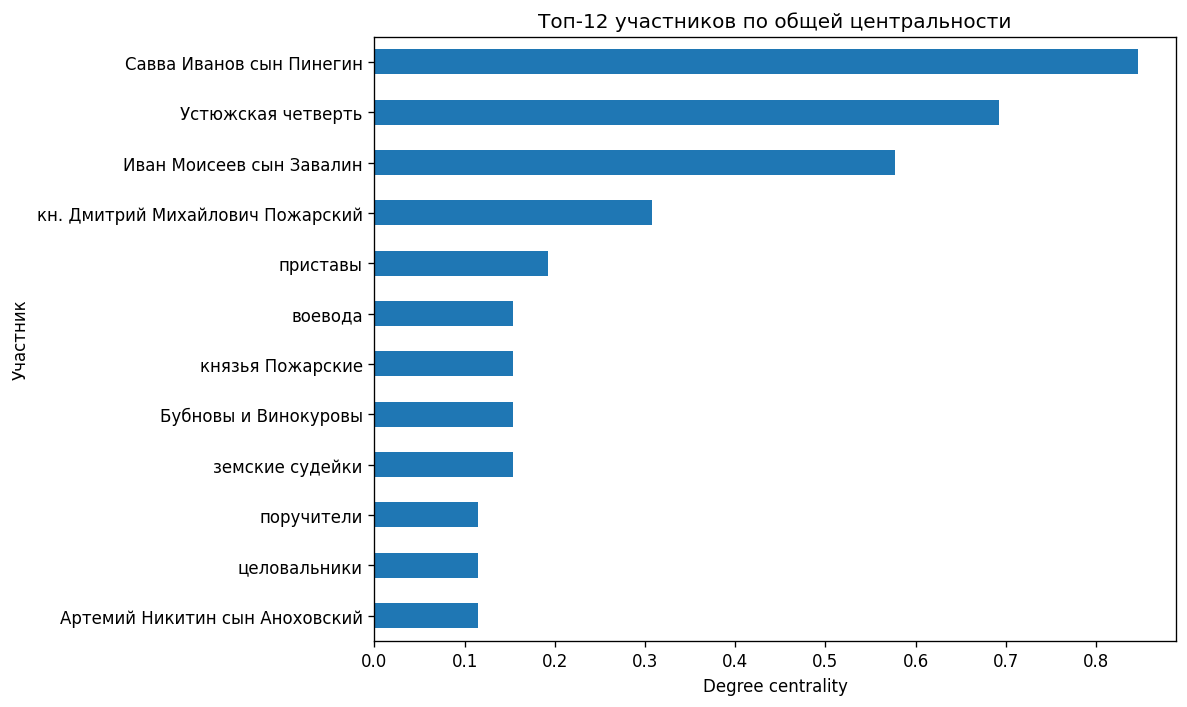

In [109]:
top_central = centrality_df.head(12).sort_values('degree_centrality')

fig, ax = plt.subplots(figsize=(10, 6))
top_central.plot(x='node', y='degree_centrality', kind='barh', ax=ax, legend=False)
ax.set_title('Топ-12 участников по общей центральности')
ax.set_xlabel('Degree centrality')
ax.set_ylabel('Участник')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_top_degree_centrality.png', bbox_inches='tight')
plt.show()


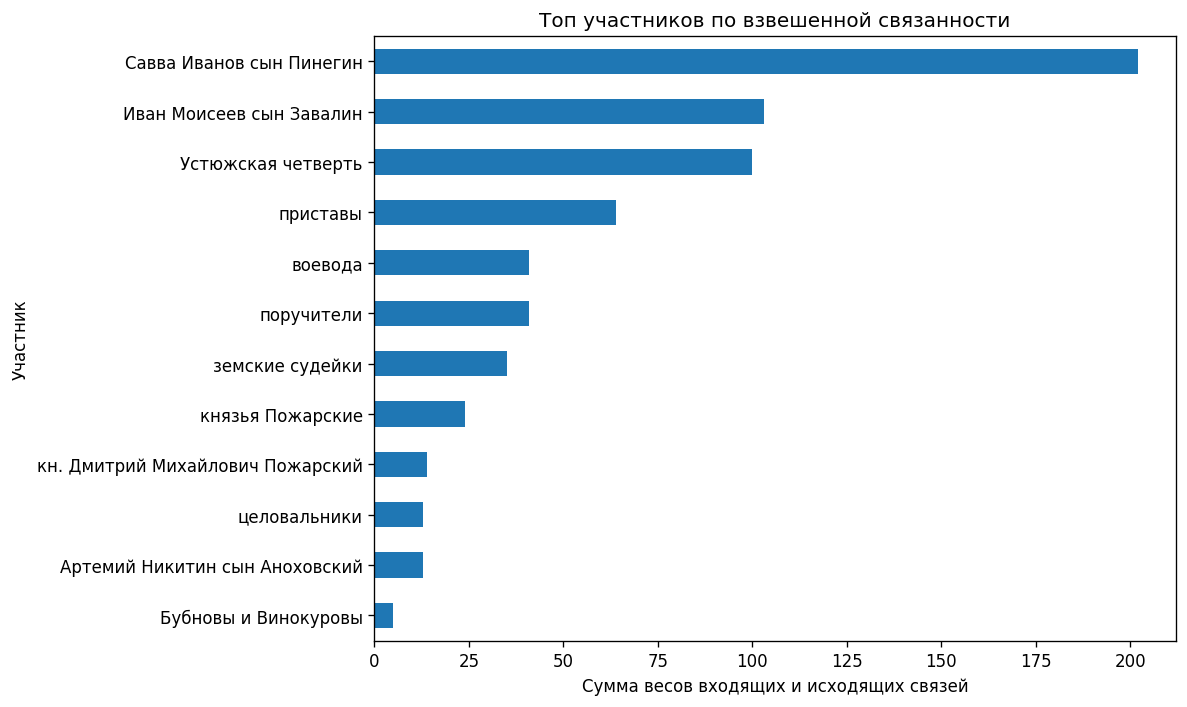

In [110]:
top_weighted = centrality_df.head(12).sort_values('weighted_degree')

fig, ax = plt.subplots(figsize=(10, 6))
top_weighted.plot(x='node', y='weighted_degree', kind='barh', ax=ax, legend=False)
ax.set_title('Топ участников по взвешенной связанности')
ax.set_xlabel('Сумма весов входящих и исходящих связей')
ax.set_ylabel('Участник')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_top_weighted_degree.png', bbox_inches='tight')
plt.show()


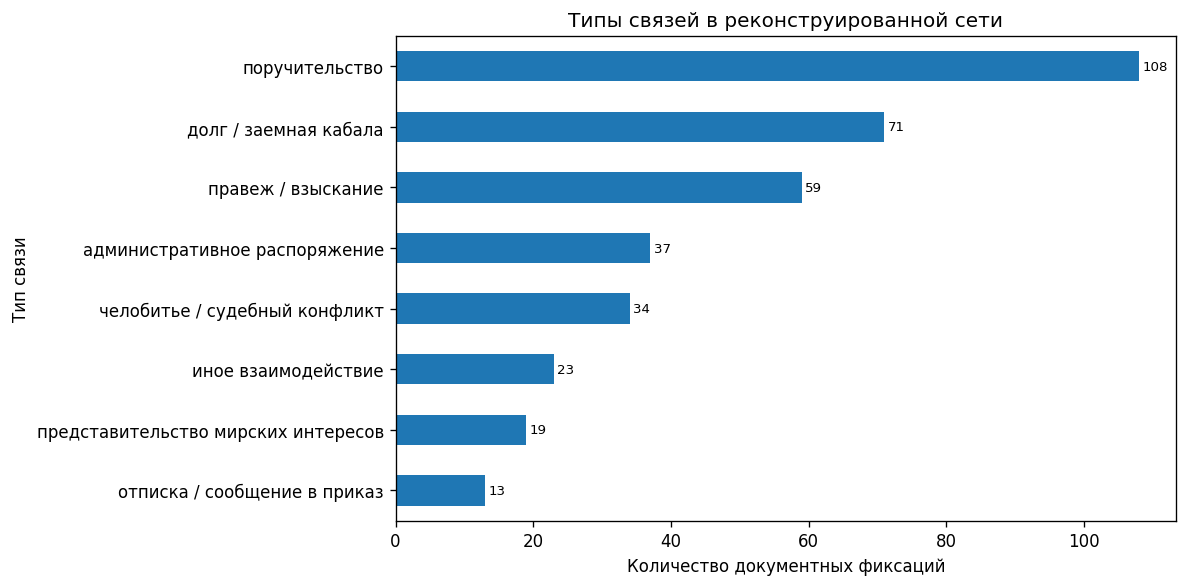

,Количество фиксаций
relation_type,
поручительство,108
долг / заемная кабала,71
правеж / взыскание,59
административное распоряжение,37
челобитье / судебный конфликт,34
иное взаимодействие,23
представительство мирских интересов,19
отписка / сообщение в приказ,13


In [111]:
relation_counts = edges_df.groupby('relation_type')['weight'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
relation_counts.plot(kind='barh', ax=ax)
ax.set_title('Типы связей в реконструированной сети')
ax.set_xlabel('Количество документных фиксаций')
ax.set_ylabel('Тип связи')
for i, v in enumerate(relation_counts):
    ax.text(v + 0.5, i, str(int(v)), va='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / '10_relation_types.png', bbox_inches='tight')
plt.show()

display(relation_counts.sort_values(ascending=False).rename('Количество фиксаций').to_frame())


## 9. Визуализация сети

Размер узла зависит от общей центральности. Толщина ребра зависит от веса связи, то есть от количества документов, где такая связь была зафиксирована. Для читаемости выводится только основной граф


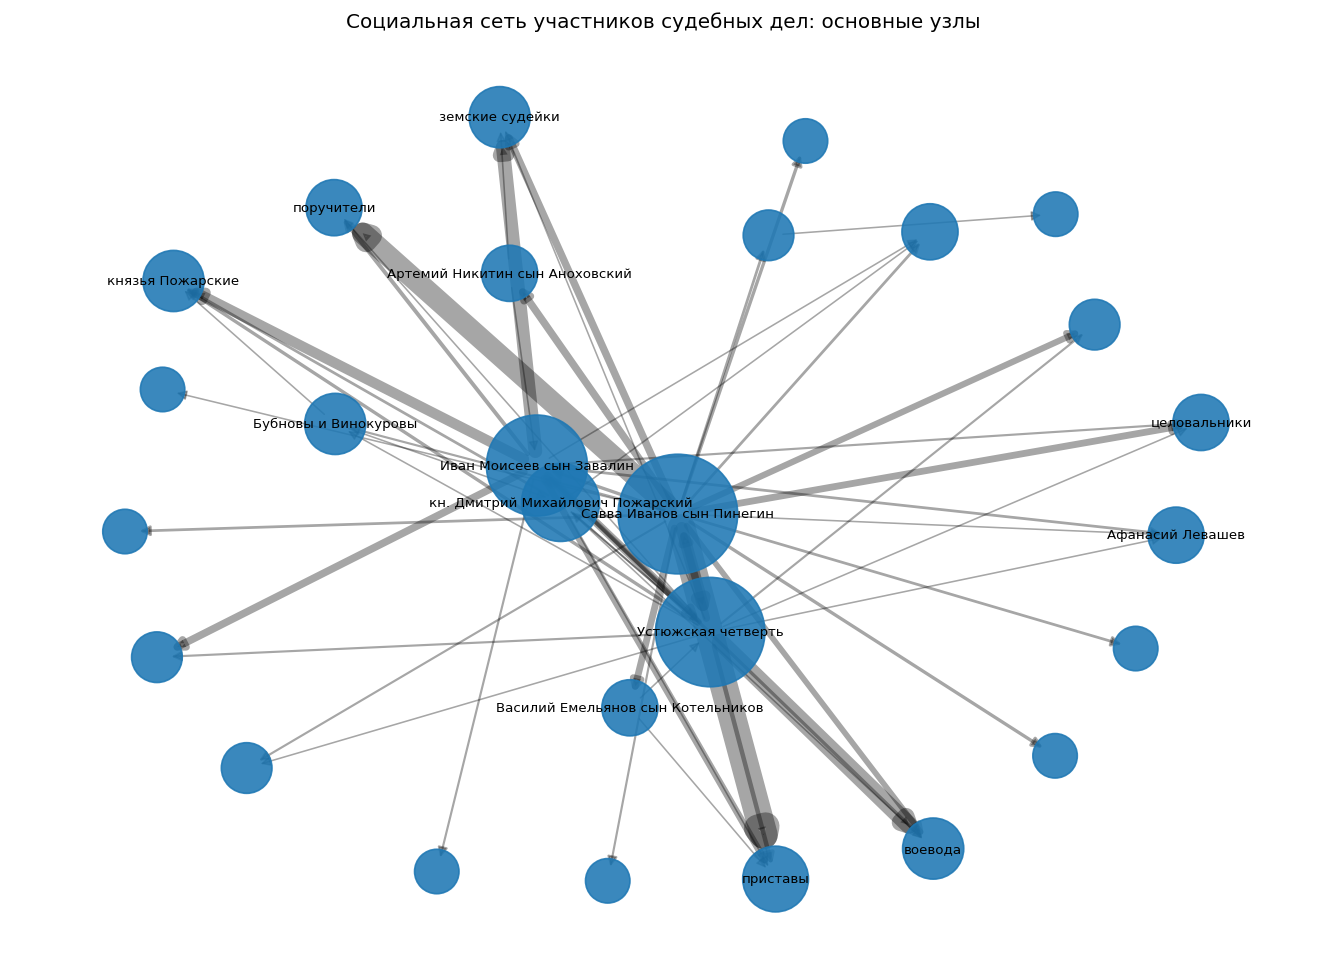

In [112]:
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.9, seed=42, weight='weight', iterations=80)

node_sizes = [500 + 5500 * degree_c[n] for n in G.nodes()]
edge_widths = [0.6 + 0.35 * G[u][v].get('weight', 1) for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.88, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.35, arrows=True, arrowsize=12, ax=ax)

# Чтобы граф не превращался в нечитаемое «облако», подписываем только самые центральные узлы
top_label_nodes = set(centrality_df.head(14)['node'])
labels = {n: n for n in G.nodes() if n in top_label_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)

ax.set_title('Социальная сеть участников судебных дел: основные узлы')
ax.axis('off')
plt.savefig(FIG_DIR / '11_network_static.png', bbox_inches='tight')
plt.show()


Особенно выделяется посредник Савва и Устюжская четверть, куда было направлено большинство челобитных

In [113]:

!pip install pandas openpyxl networkx pyvis -q

import re
from pathlib import Path
import itertools
import pandas as pd
import networkx as nx
from pyvis.network import Network
from IPython.display import HTML, display

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

files = (
    list(Path(".").glob("**/защита_общины_199*.xlsx")) +
    list(Path("/mnt/data").glob("защита_общины_199*.xlsx"))
)

if not files:
    raise FileNotFoundError("Файл защита_общины_199.xlsx не найден")

EXCEL_PATH = files[0]


df = pd.read_excel(EXCEL_PATH)


# Делаем общий текст строки из всех колонок
df["text"] = df.fillna("").astype(str).agg(" ".join, axis=1)

# Участники и варианты написания
MAIN = "Савва Иванов сын Пинегин"

PATTERNS = {
    MAIN: r"савк\w*|савв\w*|сава.*?(пинег|пенег|пинеж|пенеж)",
    "Артемий Никитин сын Аноховский": r"артем\w+|ортем\w+|аноховск|оноховск",
    "Федор Григорьев сын Болтин": r"фед\w+.*?болтин",
    "Иван Романов": r"иван\w+.*?романов|ивашк\w+.*?раманов",
    "Павел Кабаков": r"пав\w+.*?кабак",
    "Федор Печацын": r"фед\w+.*?печац",
    "Филипп Яглин / Тяглин": r"фил\w+.*?(яглин|тяглин)",
    "Иван Семенов": r"иван\w+.*?семенов|ивашк\w+.*?семенов",
    "Иван Ходутин": r"иван\w+.*?ходутин|ивашк\w+.*?ходутин",
    "Иван Моисеев сын Завалин": r"завалин",
    "Пантелей Чириков": r"пантеле\w+.*?чириков",
    "Дмитрий Львов": r"дмитр\w+.*?львов",
    "Марк Мартемьянов": r"марк\w+.*?мартем|мартемьянов",
    "Афанасий Левашев": r"афанас\w+.*?леваш",
    "Кирилл Верещагин": r"кирил\w+.*?верещаг",
    "Иван Лукьянов сын Пинега": r"иван\w+.*?лукьян\w+.*?пинег",
    "Петр Выломаев": r"петр\w+.*?вылома",
    "Григорий Похабов": r"григор\w+.*?похаб",
    "Василий Емельянов сын Котельников": r"васил\w+.*?котельников",
    "Петр Дементьев сын Мельников": r"петр\w+.*?мельников|петрушк\w+.*?мельников",
    "Филипп Кузьмин сын Фролов": r"фил\w+.*?фролов",
    "Бубновы и Винокуровы": r"бубнов|винокур",
    "князья Пожарские": r"пожарск",
    "кн. Дмитрий Михайлович Пожарский": r"дмитр\w+.*?пожарск",
    "кн. Петр Дмитриевич Пожарский": r"петр\w+.*?пожарск",
    "кн. Михаил Васильевич Белозерский": r"михаил\w+.*?белозерск",
    "кн. Никифор Иванович Белосельский": r"никифор\w+.*?белосельск",
    "чернец Соловецкого монастыря Иосиф": r"соловецк\w+.*?иосиф|иосиф.*?соловецк",

    "посадские люди Устюга": r"посадцк\w+.*?люд|посадск\w+.*?люд",
    "волостные крестьяне / волости": r"волост",
    "земские судейки": r"земск\w+.*?суд",
    "ямские старосты": r"ямск\w+.*?старост",
    "целовальники": r"целовальник",
    "поручители": r"порук|поручител",
    "приставы": r"пристав",
    "Устюжская четверть": r"устюжск\w+.*?чет",
    "Патриарший розряд": r"патриарш\w+.*?розряд",
    "Приказ Большого дворца": r"приказ\w*.*?больш\w+.*?дворц",
    "Кирилов монастырь": r"кирилов\w+.*?монастыр",
    "Троицкий Сергиев монастырь": r"троицк\w+.*?сергиев\w+.*?монастыр|троецк\w+.*?сергиев\w+.*?монастыр",
    "Устюг Великий": r"устюг\w*.*?велик",
}

GROUPS = {
    "посадские люди Устюга",
    "волостные крестьяне / волости",
    "земские судейки",
    "ямские старосты",
    "целовальники",
    "поручители",
    "приставы",
}

INSTITUTIONS = {
    "Устюжская четверть",
    "Патриарший розряд",
    "Приказ Большого дворца",
    "Кирилов монастырь",
    "Троицкий Сергиев монастырь",
    "Устюг Великий",
}

def find_nodes(text):
    text = str(text).lower()
    found = []

    for name, pattern in PATTERNS.items():
        if re.search(pattern, text):
            found.append(name)

    # Савву добавляем только если рядом есть Пинегин / Пенегин / Пинежанин
    if MAIN in found and not re.search(r"пинег|пенег|пинеж|пенеж", text):
        found.remove(MAIN)

    return list(dict.fromkeys(found))

def node_type(name):
    if name == MAIN:
        return "main"
    if name in GROUPS:
        return "group"
    if name in INSTITUTIONS:
        return "institution"
    return "person"

# Строим полный граф
G = nx.DiGraph()

for i, row in df.iterrows():
    text = row["text"]
    nodes = find_nodes(text)

    if MAIN not in nodes:
        continue

    doc_id = str(i + 1)

    for n in nodes:
        if n not in G:
            G.add_node(n, node_type=node_type(n), docs=set())
        G.nodes[n]["docs"].add(doc_id)

    # Савва связан со всеми найденными участниками
    for n in nodes:
        if n == MAIN:
            continue

        if G.has_edge(MAIN, n):
            G[MAIN][n]["weight"] += 1
            G[MAIN][n]["docs"].add(doc_id)
        else:
            G.add_edge(MAIN, n, weight=1, docs={doc_id})

    # немного связей между остальными, чтобы была сеть
    others = [n for n in nodes if n != MAIN]

    for a, b in itertools.combinations(others[:8], 2):
        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
            G[a][b]["docs"].add(doc_id)
        else:
            G.add_edge(a, b, weight=1, docs={doc_id})

print("Полный граф:", G.number_of_nodes(), "узлов,", G.number_of_edges(), "связей")

# Оставляем фокусную сеть, чтобы не было паутины
MAX_NEIGHBORS = 28
MAX_EXTRA_EDGES = 35

H = nx.DiGraph()
H.add_node(MAIN, **G.nodes[MAIN])

main_edges = [
    (v, data["weight"], data)
    for u, v, data in G.edges(data=True)
    if u == MAIN
]

main_edges = sorted(main_edges, key=lambda x: x[1], reverse=True)[:MAX_NEIGHBORS]

keep = {MAIN} | {v for v, _, _ in main_edges}

for n in keep:
    H.add_node(n, **G.nodes[n])

for v, w, data in main_edges:
    H.add_edge(MAIN, v, weight=w, docs=data.get("docs", set()))

extra = [
    (u, v, data["weight"], data)
    for u, v, data in G.edges(data=True)
    if u in keep and v in keep and u != MAIN and v != MAIN
]

extra = sorted(extra, key=lambda x: x[2], reverse=True)[:MAX_EXTRA_EDGES]

for u, v, w, data in extra:
    H.add_edge(u, v, weight=w, docs=data.get("docs", set()))

print("Фокусный граф:", H.number_of_nodes(), "узлов,", H.number_of_edges(), "связей")

#  Визуализация
degree_c = nx.degree_centrality(H)

net = Network(
    height="760px",
    width="100%",
    directed=True,
    notebook=True,
    cdn_resources="in_line"
)

net.set_options("""
{
  "physics": {
    "enabled": true,
    "solver": "barnesHut",
    "barnesHut": {
      "gravitationalConstant": -650,
      "centralGravity": 0.035,
      "springLength": 260,
      "springConstant": 0.006,
      "damping": 0.92,
      "avoidOverlap": 0.35
    },
    "stabilization": {
      "enabled": true,
      "iterations": 1000,
      "fit": true
    },
    "maxVelocity": 4,
    "minVelocity": 0.12,
    "timestep": 0.18
  },
  "interaction": {
    "dragNodes": true,
    "dragView": true,
    "zoomView": true,
    "hover": true
  },
  "edges": {
    "smooth": {
      "enabled": true,
      "type": "curvedCW",
      "roundness": 0.16
    }
  }
}
""")

# Начальные координаты, чтобы схема была аккуратнее
pos = nx.spring_layout(
    H.to_undirected(),
    seed=42,
    k=1.8,
    iterations=300,
    weight="weight"
)

pos[MAIN] = (-0.35, 0)

SCALE = 1300

for n, data in H.nodes(data=True):
    typ = data.get("node_type", "")
    x, y = pos[n]

    if n == MAIN:
        size = 50
    elif typ in ["group", "institution"]:
        size = 30
    else:
        size = 22

    net.add_node(
        n,
        label=n,
        x=float(x * SCALE),
        y=float(y * SCALE),
        size=size,
        color="#9fbdf5",
        title=(
            f"Тип: {typ}<br>"
            f"Центральность: {degree_c.get(n, 0):.3f}<br>"
            f"Документов: {len(data.get('docs', []))}"
        )
    )

for u, v, data in H.edges(data=True):
    weight = data.get("weight", 1)

    net.add_edge(
        u,
        v,
        width=min(9, 1 + weight * 0.45),
        arrows="to",
        title=f"Вес: {weight}<br>Документы: {', '.join(sorted(data.get('docs', [])))}"
    )

html_path = OUTPUT_DIR / "excel_savva_network_short.html"
net.write_html(str(html_path), notebook=False)

print("Граф сохранен:", html_path)

display(HTML(html_path.read_text(encoding="utf-8")))

Полный граф: 27 узлов, 93 связей
Фокусный граф: 27 узлов, 61 связей
Граф сохранен: outputs/excel_savva_network_short.html


## **Сеть участников судопроизводства на основе сырых данных**

In [114]:

!pip install python-docx pyvis networkx pandas -q

import re
import itertools
from pathlib import Path
from collections import defaultdict

import pandas as pd
import networkx as nx
from docx import Document
from pyvis.network import Network
from IPython.display import HTML, display

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Word-файл
files = list(Path(".").glob("**/Челобитные_все_1*.docx")) + list(Path("/mnt/data").glob("Челобитные_все_1*.docx"))
if not files:
    raise FileNotFoundError("Загрузи файл Челобитные_все_1!.docx в Colab/Jupyter")

DOCX_PATH = files[0]
print("Используется файл:", DOCX_PATH)

# Читаем текст
doc = Document(DOCX_PATH)
text = "\n".join(p.text.strip() for p in doc.paragraphs if p.text.strip())
text = text.replace("[", "").replace("]", "")

#Делим на документы по №
docs = [
    x.strip()
    for x in re.split(r"(?=\n?\s*№\s*\d+)", text)
    if re.match(r"\s*№\s*\d+", x)
]

print("Найдено документов по маркеру №:", len(docs))

SAVVA = "Савва Иванов сын Пинегин"

#  Варианты имени Саввы
SAVVA_RE = re.compile(
    r"(савк\w*|савв\w*|сава)\s+(?:иван\w+\s*)?(?:сын\w*\s*)?"
    r"(пинег\w*|пенег\w*|пинежан\w*|пенежан\w*)",
    re.IGNORECASE
)

def is_savva_doc(s):
    low = s.lower()
    return bool(SAVVA_RE.search(low)) or (
        ("савк" in low or "савв" in low)
        and ("пинег" in low or "пенег" in low or "пинеж" in low or "пенеж" in low)
    )

# Кого и что ищем в docx
NODES = {
    # люди
    "Артемий Никитин / Оноховский": [r"ортем\w+\s+(никит|микит|онох|анох)", r"артем\w+\s+(никит|онох|анох)"],
    "Федор Болтин": [r"фед\w+\s+болтин"],
    "Иван Романов": [r"иван\w*\s+романов", r"ивашк\w*\s+раманов"],
    "Павел Кабаков": [r"павл\w+\s+кабак"],
    "Федор Печацын": [r"фед\w+\s+печац"],
    "Филипп Яглин / Тяглин": [r"фил\w+\s+(яглин|тяглин)"],
    "Иван Семенов": [r"иван\w*\s+семенов", r"ивашк\w*\s+семенов"],
    "Иван Ходутин": [r"иван\w*\s+ходутин", r"ивашк\w*\s+ходутин"],
    "Иван Моисеев сын Завалин": [r"иван\w*\s+.*?завалин", r"ивашк\w*\s+завалин"],
    "Пантелей Чириков": [r"пантеле\w+\s+чириков"],
    "Дмитрий Львов": [r"дмитр\w+\s+львов"],
    "Марк Мартемьянов": [r"марк\w+\s+мартем"],
    "Степан Дурляев": [r"степан\w+\s+дурля"],
    "Василий Котельников": [r"васил\w+\s+котельников", r"васк\w+\s+котельников"],
    "Григорий Похабов": [r"григор\w+\s+похаб"],
    "Петр Выломаев": [r"петр\w+\s+вылома"],
    "Петр Мельников": [r"петр\w+\s+мельников", r"петрушк\w+\s+мельников"],
    "Сава Мельников": [r"сав\w+\s+мельников"],
    "Филипп Фролов": [r"фил\w+\s+фролов"],
    "Афанасий Левшин": [r"афанас\w+\s+левшин"],
    "Дмитрий Михайлович Пожарский": [r"дмитр\w+.*?пожарск"],
    "Петр Дмитриевич Пожарский": [r"петр\w+.*?пожарск"],
    "Бубновы и Винокуровы": [r"бубнов", r"винокур"],
    "Гордей Григорьев": [r"горде\w+\s+григор"],
    "Никита Тарасов": [r"никит\w+\s+тарас", r"микит\w+\s+тарас"],
    "Андрей Болтин": [r"андр\w+\s+болтин", r"ондр\w+\s+болтин"],

    # коллективные субъекты и учреждения
    "посадские люди Устюга": [r"посадцк\w+\s+люд", r"посадск\w+\s+люд"],
    "волостные крестьяне / волости": [r"волостн\w+\s+крестьян", r"волост"],
    "земские судейки": [r"земск\w+\s+суд"],
    "ямские старосты": [r"ямск\w+\s+старост"],
    "целовальники": [r"целовальник"],
    "поручители": [r"порук", r"поручн"],
    "приставы": [r"пристав"],
    "Устюжская четверть": [r"устюжск\w+\s+чет"],
    "Приказ Большого дворца": [r"приказ\w*\s+больш\w+\s+дворц"],
    "Патриарший розряд": [r"патриарш\w+\s+розряд"],
    "Кирилов монастырь": [r"кирилов\w+\s+монастыр"],
    "Троицкий Сергиев монастырь": [r"троицк\w+\s+сергиев\w+\s+монастыр"],
    "Устюг Великий": [r"устюг\w*\s+велик"],
}

INSTITUTIONS = {
    "посадские люди Устюга", "волостные крестьяне / волости", "земские судейки",
    "ямские старосты", "целовальники", "поручители", "приставы",
    "Устюжская четверть", "Приказ Большого дворца", "Патриарший розряд",
    "Кирилов монастырь", "Троицкий Сергиев монастырь", "Устюг Великий"
}

def find_nodes(s):
    low = s.lower()
    found = []
    for name, patterns in NODES.items():
        if any(re.search(p, low) for p in patterns):
            found.append(name)
    return found

def doc_type(s):
    head = s[:800].lower()
    if "челобитн" in head:
        return "челобитная"
    if "указная грамота" in head or "грамота" in head:
        return "указная грамота"
    if "кабал" in head:
        return "кабала"
    if "поручн" in head:
        return "поручная запись"
    if "допрос" in head:
        return "допрос"
    return "документ"

def relation_for(node, dtype):
    if node in {"Устюжская четверть", "Приказ Большого дворца", "Патриарший розряд"}:
        return "приказное производство / обращение"
    if node in {"земские судейки", "ямские старосты", "целовальники", "посадские люди Устюга", "волостные крестьяне / волости"}:
        return "ответчики / община"
    if node in {"поручители", "приставы"}:
        return "процедурная связь"
    if "Мельников" in node or "Фролов" in node:
        return "исковая связь"
    if "Пожар" in node or "Завалин" in node:
        return "долговая связь"
    return dtype

# Строим граф
G = nx.DiGraph()
G.add_node(SAVVA, node_type="main", docs=set())

rows = []

for d in docs:
    if not is_savva_doc(d[:6000]):
        continue

    doc_id = re.search(r"№\s*(\d+)", d)
    doc_id = doc_id.group(1) if doc_id else "?"

    year = re.search(r"\b(16\d{2})\s*г", d[:800])
    year = int(year.group(1)) if year else None

    dtype = doc_type(d)
    title = " ".join(d.splitlines()[:3])[:250]

    part = d[:8000]
    found = find_nodes(part)

    G.nodes[SAVVA]["docs"].add(doc_id)

    for node in found:
        ntype = "institution" if node in INSTITUTIONS else "person"

        if node not in G:
            G.add_node(node, node_type=ntype, docs=set())

        G.nodes[node]["docs"].add(doc_id)

        rel = relation_for(node, dtype)

        if G.has_edge(SAVVA, node):
            G[SAVVA][node]["weight"] += 1
            G[SAVVA][node]["docs"].add(doc_id)
            G[SAVVA][node]["relations"].add(rel)
        else:
            G.add_edge(SAVVA, node, weight=1, docs={doc_id}, relations={rel})


    for a, b in itertools.combinations(found[:14], 2):
        if a == b:
            continue

        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
            G[a][b]["docs"].add(doc_id)
            G[a][b]["relations"].add("совместное участие в документе")
        else:
            G.add_edge(a, b, weight=1, docs={doc_id}, relations={"совместное участие в документе"})

    rows.append({
        "№ документа": doc_id,
        "Год": year,
        "Тип": dtype,
        "Заголовок": title,
        "Найденные участники": "; ".join(found)
    })

print("Документов с Саввой:", len(rows))
print("Узлов:", G.number_of_nodes())
print("Связей:", G.number_of_edges())

# Таблицы для проверки
docs_df = pd.DataFrame(rows)
docs_df.to_csv(OUTPUT_DIR / "savva_network_from_docx_documents.csv", index=False, encoding="utf-8-sig")

centrality = nx.degree_centrality(G)

centrality_df = pd.DataFrame([
    {
        "Участник": n,
        "Тип": G.nodes[n]["node_type"],
        "Центральность": centrality[n],
        "Взвешенная степень": G.degree(n, weight="weight"),
        "Документов": len(G.nodes[n]["docs"]),
    }
    for n in G.nodes()
]).sort_values("Взвешенная степень", ascending=False)

centrality_df.to_csv(OUTPUT_DIR / "savva_network_from_docx_centrality.csv", index=False, encoding="utf-8-sig")
display(centrality_df.head(25))

# Стабильная визуализация, без скачков
UG = G.to_undirected()
pos = nx.spring_layout(UG, seed=42, k=1.5, iterations=250, weight="weight")

# Савву фиксируем ближе к центру-слева, как на твоей схеме
pos[SAVVA] = (-0.35, 0)

scale = 1200

net = Network(
    height="800px",
    width="100%",
    directed=True,
    notebook=True,
    cdn_resources="in_line"
)

net.toggle_physics(False)

for n, data in G.nodes(data=True):
    ntype = data["node_type"]

    if ntype == "main":
        color, size = "#ff7777", 60
    elif ntype == "institution":
        color, size = "#ffd27f", 34
    else:
        color, size = "#9fc2ff", 26

    x, y = pos[n]

    net.add_node(
        n,
        label=n,
        color=color,
        size=size,
        x=float(x * scale),
        y=float(y * scale),
        physics=False,
        title=(
            f"<b>{n}</b><br>"
            f"Тип: {ntype}<br>"
            f"Документов: {len(data['docs'])}<br>"
            f"Центральность: {centrality[n]:.3f}<br>"
            f"Взвешенная степень: {G.degree(n, weight='weight')}"
        )
    )

for a, b, data in G.edges(data=True):
    rels = ", ".join(sorted(data["relations"]))
    docs_list = ", ".join(sorted(data["docs"]))

    net.add_edge(
        a,
        b,
        value=data["weight"],
        arrows="to",
        title=(
            f"<b>{a} → {b}</b><br>"
            f"Связь: {rels}<br>"
            f"Вес: {data['weight']}<br>"
            f"Документы №: {docs_list}"
        )
    )

net.set_options("""
{
  "physics": {"enabled": false},
  "interaction": {
    "dragNodes": true,
    "dragView": true,
    "zoomView": true,
    "hover": true
  },
  "nodes": {
    "font": {"size": 18}
  },
  "edges": {
    "smooth": {
      "enabled": true,
      "type": "curvedCW",
      "roundness": 0.18
    }
  }
}
""")

html_path = OUTPUT_DIR / "savva_network_from_docx_like_scheme.html"
net.write_html(str(html_path), notebook=False)

print("Интерактивная схема сохранена:", html_path)
display(HTML(html_path.read_text(encoding="utf-8")))

Используется файл: Челобитные_все_1!.docx
Найдено документов по маркеру №: 22
Документов с Саввой: 20
Узлов: 35
Связей: 427


,Участник,Тип,Центральность,Взвешенная степень,Документов
0,Савва Иванов сын Пинегин,main,1.000000,243,20
7,волостные крестьяне / волости,institution,0.970588,176,16
8,земские судейки,institution,0.970588,176,16
4,Пантелей Чириков,person,0.941176,166,15
18,посадские люди Устюга,institution,0.941176,155,14
9,целовальники,institution,0.970588,150,16
27,приставы,institution,0.823529,132,16
10,Устюжская четверть,institution,0.823529,126,17
20,поручители,institution,0.735294,119,16
5,Никита Тарасов,person,0.941176,98,8


Интерактивная схема сохранена: outputs/savva_network_from_docx_like_scheme.html


## Сохранение результатов



In [115]:
# Сохраняем таблицы для репозитория
df.to_csv(OUTPUT_DIR / 'source_rows_cleaned_197_rows.csv', index=False, encoding='utf-8-sig')
docs_df.to_csv(OUTPUT_DIR / 'documents_expanded_199_docs.csv', index=False, encoding='utf-8-sig')
edges_df.to_csv(OUTPUT_DIR / 'network_edges.csv', index=False, encoding='utf-8-sig')
nodes_df.to_csv(OUTPUT_DIR / 'network_nodes.csv', index=False, encoding='utf-8-sig')
centrality_df.to_csv(OUTPUT_DIR / 'network_centrality.csv', index=False, encoding='utf-8-sig')
strat.to_csv(OUTPUT_DIR / 'protection_strategies_summary.csv', index=False, encoding='utf-8-sig')



## Итог
Материалы мирских челобитных Устюга Великого первой половины XVII века позволяют реконструировать сложную социальную сеть судебных взаимодействий, в которой переплетались легальные и неформальные практики. Как показывает дело Саввы Пинегина, община обладала разветвленной системой защиты интересов, включавшей наем посыльщиков для судебного представительства в Москве, коллективное челобитье, а также механизмы внутреннего контроля за выборными лицами.
В рамках этой социальной сети ключевыми узлами выступали посадские люди, выборные представители (целовальники, старосты), наемники и ответчики по искам. Причины судебных разбирательств систематизировались вокруг экономических споров (земельных, торговых, пошлинных), административных конфликтов и нарушений мирских полномочий.
Принципиальным выводом является то, что социальная сеть судебных дел действовала не только вовне, но и внутри общины. Мир одновременно нанимал представителя и отказывал ему в вознаграждении, уклонялся от выбора ответчиков по его искам и использовал коллективные челобитные как инструмент давления. Коллективная челобитная устюжан против Саввы Пинегина стала прямым ответом на его попытку договориться с ответчиком в обход общины. Таким образом, социальная сеть судебных дел включала горизонтальные связи между посадскими, вертикальные - между общиной и ее выборными лицами, а также внешние связи с московскими приказными структурами через наемных представителей. Защита интересов в этой сети строилась на балансе легальных процедур и неформальных практик.

